In [80]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import os
import json

from tqdm import tqdm

In [3]:
baseline_idx = np.load("/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data/baseline_idx_test.npy")

In [10]:
reg_mu    = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_mu.npy")
reg_sigma = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_sigma.npy")

experiments_dir = "/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data"

seeds = [1, 7, 42, 85, 123, 156, 234, 301, 412, 500, 617, 724, 836, 901, 999, 1042]

param_names = ["T_eff (K)", "log g (dex)", "[Fe/H] (dex)"]

lamost_flux = np.load("/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data/experiment_1/lamost_flux.npy")
lamost_true_params = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/inspection/model_inspection/lamost_true_reg.npy")

In [15]:
vae_maes = {name: [] for name in param_names}

for seed in tqdm(seeds):

    dir_seed = os.path.join(experiments_dir, f"experiment_{seed}")

    try:
        lamost_pred = np.load(os.path.join(dir_seed, "lamost_preds_reg.npy"))
        lamost_true = np.load(os.path.join(dir_seed, "lamost_true_reg.npy"))

        for i, (name, sigma) in enumerate(zip(param_names, reg_sigma)):
            mae = np.mean(np.abs(lamost_pred[baseline_idx, i] - lamost_true[baseline_idx, i])) * sigma

            vae_maes[name].append(mae)

    except FileNotFoundError as e:
        print(f"Seed {seed} missing: {e}")

for name in param_names:
    vae_maes[name] = np.array(vae_maes[name])

100%|██████████| 16/16 [00:00<00:00, 1907.80it/s]


In [66]:
with open("/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data/mean_mae_reg.json", "r", encoding=   "utf-8") as mae_mean_file:
    mae_mean = json.load(mae_mean_file)

with open("/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data/ridge_mae_reg.json", "r", encoding=   "utf-8") as ridge_mean_file:
    mae_ridge = json.load(ridge_mean_file)

In [38]:
for i, name in enumerate(param_names):
    vae_arr = vae_maes[name]
    
    print((vae_arr < mae_mean[name]).mean())

0.125
0.0
0.0625


In [39]:
h3_results = {}

for i, name in enumerate(param_names):
    vae_arr = vae_maes[name]

    pct_beats_mean  = (vae_arr < mae_mean[name]).mean()  * 100
    pct_beats_ridge = (vae_arr < mae_ridge[name]).mean() * 100

    print(f"\n{name}:")
    print(f"  Mean predictor : {mae_mean[name]:.4f}")
    print(f"  Ridge          : {mae_ridge[name]:.4f}")
    print(f"  VAE            : {vae_arr.mean():.4f} ± {vae_arr.std():.4f}")
    print(f"  Beats mean predictor in {pct_beats_mean:.0f}% of seeds")
    print(f"  Beats ridge     in {pct_beats_ridge:.0f}% of seeds")

    if pct_beats_mean == 100:
        print(f"  H3 vs mean: STRONGLY SUPPORTED")
    elif pct_beats_mean >= 80:
        print(f"  H3 vs mean: SUPPORTED")
    else:
        print(f"  H3 vs mean: WEAK ")

    if pct_beats_ridge == 100:
        print(f"  H3 vs ridge: STRONGLY SUPPORTED")
    elif pct_beats_ridge >= 80:
        print(f"  H3 vs ridge: SUPPORTED ")
    else:
        print(f"  H3 vs ridge: WEAK ")

    h3_results[name] = {
        "mae_mean_pred"       : float(mae_mean[name]),
        "mae_ridge"           : float(mae_ridge[name]),
        "mae_vae_mean"        : float(vae_arr.mean()),
        "mae_vae_std"         : float(vae_arr.std()),
        "pct_beats_mean"      : float(pct_beats_mean),
        "pct_beats_ridge"     : float(pct_beats_ridge)
    }

with open(os.path.join(experiments_dir, "h3_results.json"), "w") as f:
    json.dump(h3_results, f, indent=2)
print("\nSaved h3_results.json")


T_eff (K):
  Mean predictor : 675.7192
  Ridge          : 130.6962
  VAE            : 908.6834 ± 197.6679
  Beats mean predictor in 12% of seeds
  Beats ridge     in 0% of seeds
  H3 vs mean: WEAK 
  H3 vs ridge: WEAK 

log g (dex):
  Mean predictor : 0.5206
  Ridge          : 0.1875
  VAE            : 0.7751 ± 0.1139
  Beats mean predictor in 0% of seeds
  Beats ridge     in 0% of seeds
  H3 vs mean: WEAK 
  H3 vs ridge: WEAK 

[Fe/H] (dex):
  Mean predictor : 0.5041
  Ridge          : 0.1046
  VAE            : 0.6762 ± 0.1046
  Beats mean predictor in 6% of seeds
  Beats ridge     in 0% of seeds
  H3 vs mean: WEAK 
  H3 vs ridge: WEAK 

Saved h3_results.json


#### MAE Bar Graph

In [ ]:
x = np.arange(len(param_names))
width = 0.25

[0 1 2]


In [67]:
print(mae_mean)

{'T_eff (K)': 675.7191567329936, 'log g (dex)': 0.5206372313408641, '[Fe/H] (dex)': 0.5040842877313859}


In [68]:
mae_mean = [mae_mean[name] for name in param_names]
mae_ridge = [mae_ridge[name] for name in param_names]

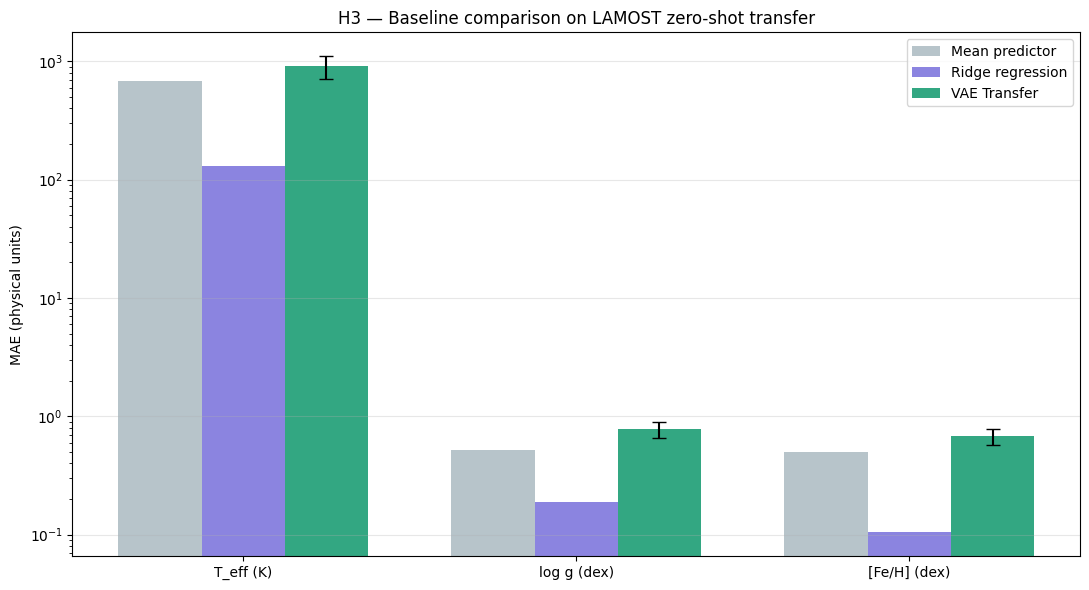

In [72]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width, mae_mean,
       width, label="Mean predictor",
       color="#B0BEC5", alpha=0.9)

ax.bar(x, mae_ridge,
       width, label="Ridge regression",
       color="#7F77DD", alpha=0.9)

ax.bar(x + width,
       [vae_maes[n].mean() for n in param_names],
       width,
       yerr=[vae_maes[n].std() for n in param_names],
       capsize=5,
       label="VAE Transfer",
       color="#1D9E75", alpha=0.9)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.set_ylabel("MAE (physical units)")
ax.set_title("H3 — Baseline comparison on LAMOST zero-shot transfer")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "h3_mae_bar.png"), dpi=150)
plt.show()

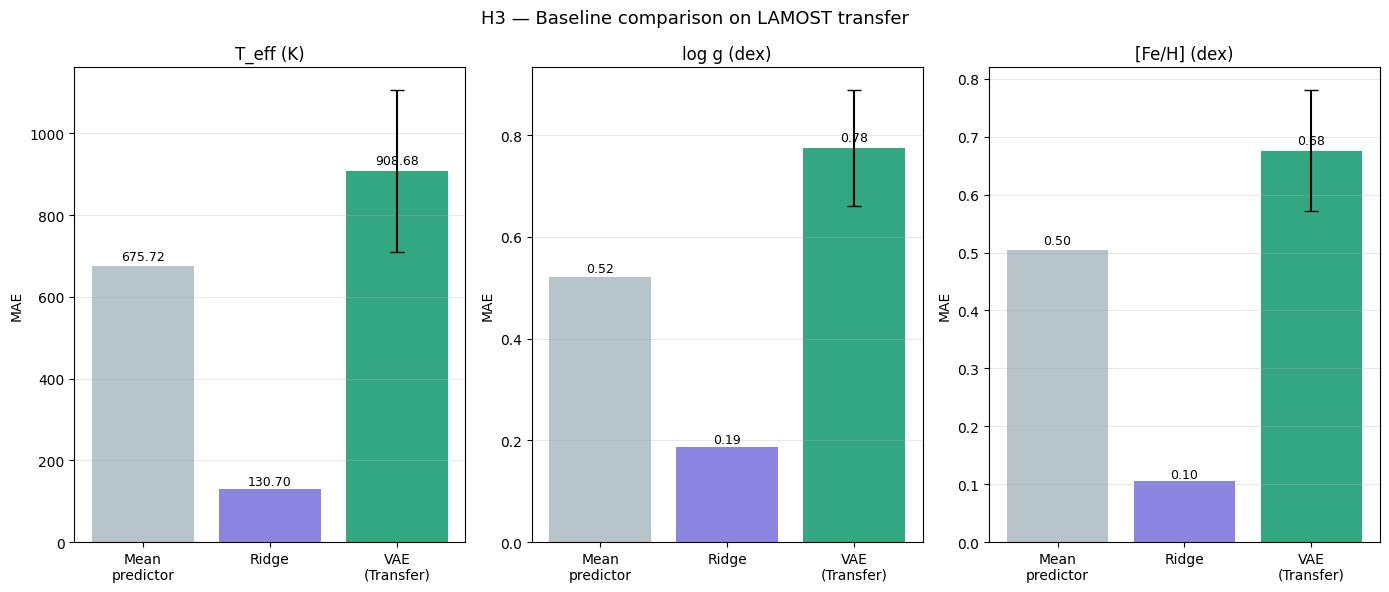

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, name, mean_val, ridge_val in zip(
        axes, param_names, mae_mean, mae_ridge):

    vae_arr = vae_maes[name]

    bars = ax.bar(
        ["Mean\npredictor", "Ridge", "VAE\n(Transfer)"],
        [mean_val, ridge_val, vae_arr.mean()],
        color=["#B0BEC5", "#7F77DD", "#1D9E75"],
        alpha=0.9
    )

    # error bar on VAE only
    ax.errorbar(
        x=2,
        y=vae_arr.mean(),
        yerr=vae_arr.std(),
        fmt="none",
        color="black",
        capsize=5,
        linewidth=1.5
    )

    ax.set_title(name)
    ax.set_ylabel("MAE")
    ax.grid(alpha=0.3, axis="y")

    # annotate bar values on top
    for bar, val in zip(bars, [mean_val, ridge_val, vae_arr.mean()]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("H3 — Baseline comparison on LAMOST transfer", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "h3_mae_bar.png"), dpi=150)
plt.show()

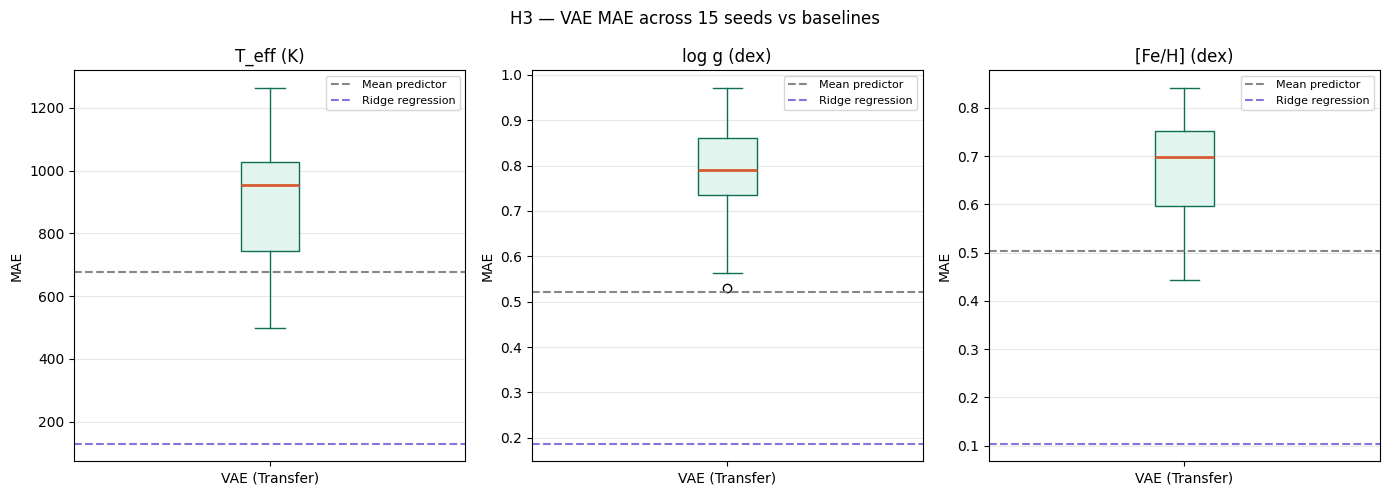

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, name, mean_val, ridge_val in zip(
        axes, param_names, mae_mean, mae_ridge):

    vae_arr = vae_maes[name]

    ax.boxplot(vae_arr,
               patch_artist=True,
               boxprops=dict(facecolor="#E1F5EE", color="#0F6E56"),
               medianprops=dict(color="#D85A30", linewidth=2),
               whiskerprops=dict(color="#0F6E56"),
               capprops=dict(color="#0F6E56"))

    ax.axhline(y=mean_val,  linestyle="--",
               color="#888780", linewidth=1.5, label="Mean predictor")
    ax.axhline(y=ridge_val, linestyle="--",
               color="#7F77DD", linewidth=1.5, label="Ridge regression")

    ax.set_title(name)
    ax.set_ylabel("MAE")
    ax.set_xticks([1])
    ax.set_xticklabels(["VAE (Transfer)"])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("H3 — VAE MAE across 15 seeds vs baselines", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "h3_mae_boxplot.png"), dpi=150)
plt.show()